# Exploratory Data Analysis for the Waste Classification Dataset

EDA is a crucial first step in any data science/ML project to analyze, understand and summarize datasets using visual tools and summary statistics before we start building models. For an image classification dataset, EDA must focus on identifying class imbalances, analyzing image resolutions and spotting any possible corrupted data to guarantee that the convolutional neural network (CNN) can train smoothly. It is worth mentioning that the dataset is said to be "already organized and labeled", but we still have to follow these steps as usual.

The dataset used in this project is the "Waste Classification", obtained from [Kaggle](https://www.kaggle.com/datasets/adithyachalla/waste-classification/data) and it contains images of nine different household waste categories.

## 1) Overview 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

In [2]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [3]:
data_dir = Path("data/cnn_waste_classification")

In [4]:
list(Path(data_dir).iterdir())

[PosixPath('data/cnn_waste_classification/9-Vegetation'),
 PosixPath('data/cnn_waste_classification/7-Plastic'),
 PosixPath('data/cnn_waste_classification/1-Cardboard'),
 PosixPath('data/cnn_waste_classification/6-Paper'),
 PosixPath('data/cnn_waste_classification/5-Miscellaneous Trash'),
 PosixPath('data/cnn_waste_classification/8-Textile Trash'),
 PosixPath('data/cnn_waste_classification/4-Metal'),
 PosixPath('data/cnn_waste_classification/3-Glass'),
 PosixPath('data/cnn_waste_classification/2-Food Organics')]

In [5]:
for folder in data_dir.iterdir():
    print(folder.name)

9-Vegetation
7-Plastic
1-Cardboard
6-Paper
5-Miscellaneous Trash
8-Textile Trash
4-Metal
3-Glass
2-Food Organics


In [6]:
folders = sorted(
    data_dir.iterdir(),
    key=lambda x: int(x.name.split("-")[0])
)

for folder in folders:
    print(folder.name)

1-Cardboard
2-Food Organics
3-Glass
4-Metal
5-Miscellaneous Trash
6-Paper
7-Plastic
8-Textile Trash
9-Vegetation


## 2) Class Distribution 

In [7]:
class_counts = {
    folder.name: len(list(folder.glob("*")))
    for folder in folders
}

class_counts

{'1-Cardboard': 461,
 '2-Food Organics': 411,
 '3-Glass': 420,
 '4-Metal': 788,
 '5-Miscellaneous Trash': 496,
 '6-Paper': 500,
 '7-Plastic': 921,
 '8-Textile Trash': 319,
 '9-Vegetation': 436}

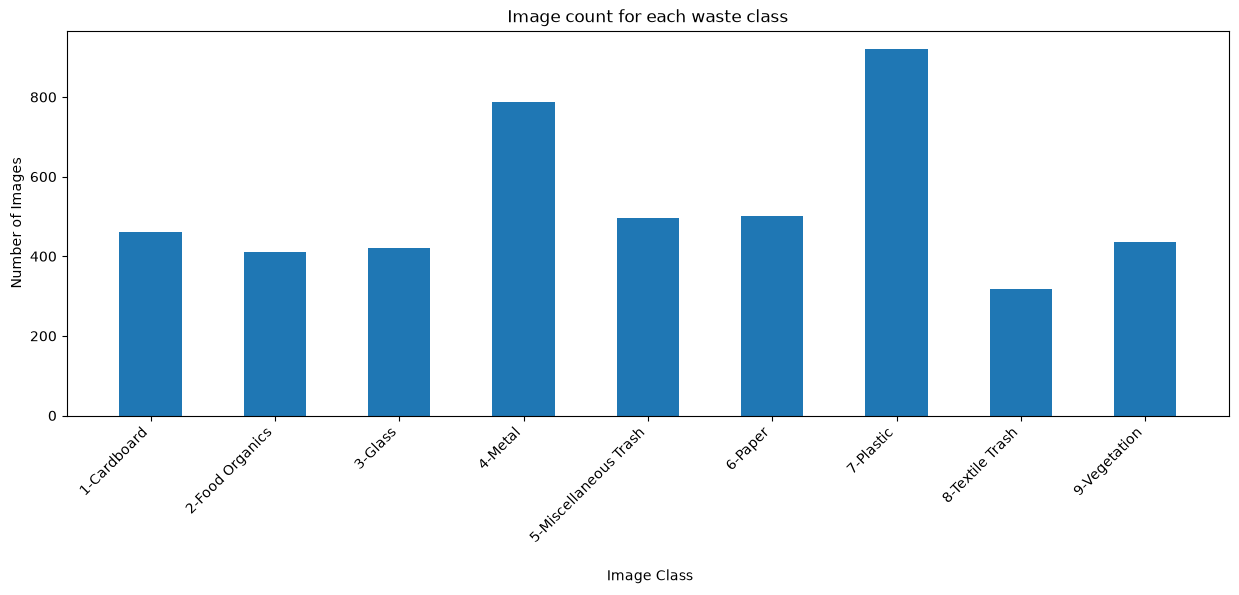

In [8]:
plt.figure(figsize=(15, 5))
plt.bar(class_counts.keys(), class_counts.values(), width=0.5)
plt.title("Image count for each waste class")
plt.xticks(rotation=45, ha="right")
plt.xlabel("\n Image Class")
plt.ylabel("Number of Images")
plt.show()

We can see that the classes are not evenly distributed. Metal and Plastic have considerably more image data compared to the other classes. Meanwhile, all of them have a relatively large number of examples, with Textile Trash being the class with the fewest examples and still having over 300 images.

## 3) Image Dimensions and Channels 

In [9]:
sizes = []
modes = []

for image_path in data_dir.rglob("*"):
    if image_path.is_file():
        with Image.open(image_path) as img:
            sizes.append(img.size)
            modes.append(img.mode)

In [10]:
set(sizes)

{(524, 524)}

In [11]:
set(modes)

{'RGB'}

Across all images, we can see that they are consistent, with the same size (524×524) and the same color channels (RGB).

## 4) Subset of Images from each Class 

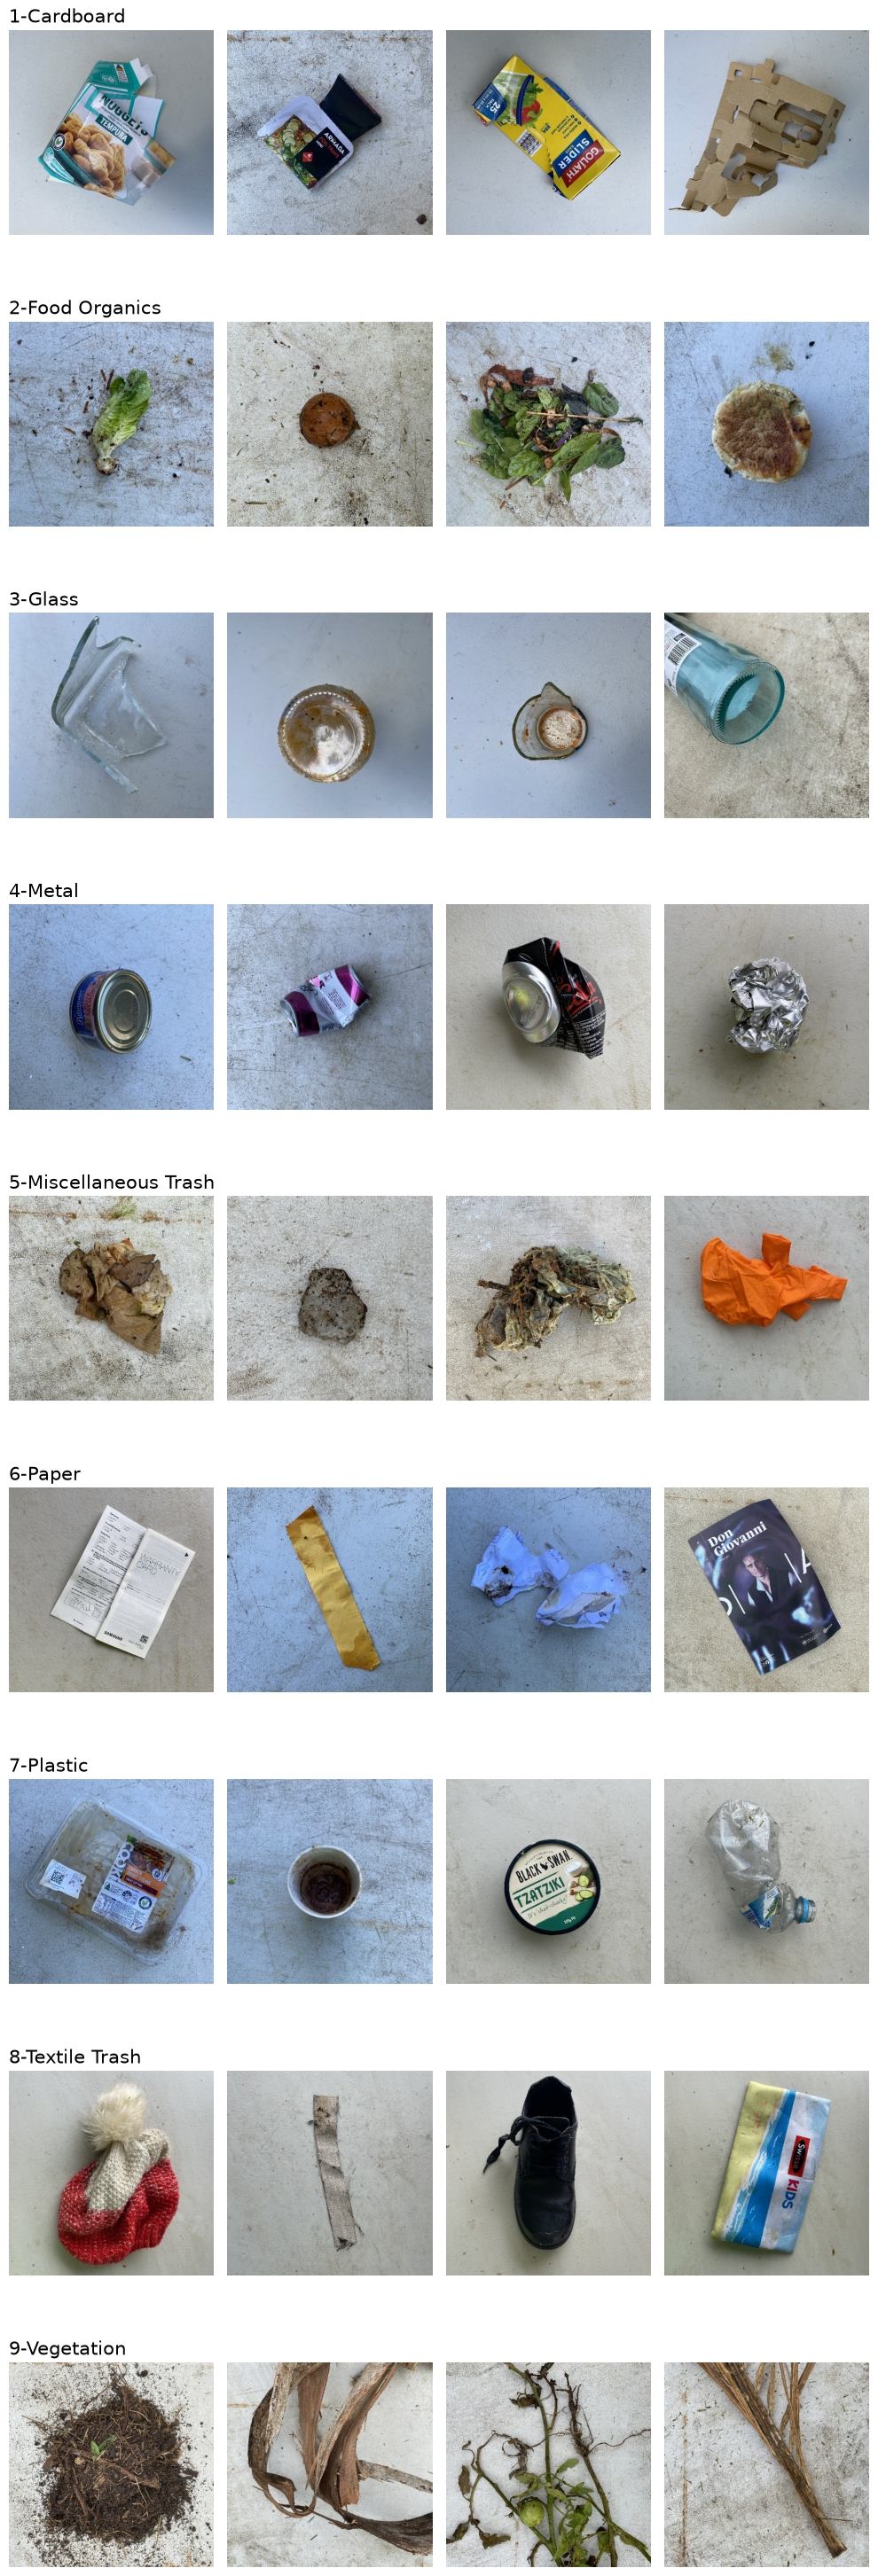

In [12]:
random.seed(15)

fig, axes = plt.subplots(len(folders), 4, figsize=(10, 30))

for row, folder in enumerate(folders):
    image_files = list(folder.glob("*"))
    selected_images = random.sample(image_files, 4)

    for col, image_path in enumerate(selected_images):
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(folder.name, loc="left", fontsize=15)

plt.tight_layout()
plt.show()